# Cross-Platform Arbitrage: Kalshi vs Polymarket on MLB Games

When both platforms list the same game, do their order books diverge enough to profit after fees?

## Method
Compare the best bid and best ask on each platform at every order book state change.\
An **arbitrage opportunity** exists when one platform's best bid exceeds the other's best ask
by more than the combined taker fees on both legs.

Two directions:
- **buy_poly**: buy on Polymarket at its ask, offset on Kalshi by buying NO at (1 − Kalshi bid).
- **buy_kalshi**: buy on Kalshi at its ask, offset on Polymarket at its bid.

### Episodes
Consecutive book states where the deviation stays open are grouped into one **episode**.\
An episode starts at the state where the books first cross and ends at the first state where they uncross.\
One episode = one opportunity. Each carries a duration, a peak deviation, and the minimum
size available at the best prices while it was open.\
Note
- episodes starting within 30 seconds of a collector start or reconnect are excluded
    - stale forward-filled book state around those events produces phantom arbs

### Fees
Both legs are taker orders. Per contract:
- Kalshi: 7¢ × p × (1 − p)
- Polymarket: 6¢ × p × (1 − p)

At a 50¢ price, total round-trip fee ≈ 3.25¢. Only episodes where the gross deviation
exceeds this fee are counted as opportunities.

### Taker delay
Polymarket enforces a 1–3 second matching delay on marketable (taker) orders in sports markets.
A taker order is accepted but held in a `delayed` status before the matching engine attempts to fill.
During that window the book can move or be consumed by other participants.
Sources disagree on the duration:
[Polymarket's Create Order docs](https://docs.polymarket.com/trading/orders/create) say 1 second,
the [Polymarket agent-skills repo](https://github.com/Polymarket/agent-skills/blob/main/order-patterns.md) says 3 seconds.

This means opportunities shorter than ~1–3s may not be executable even with
instantaneous order submission.

## Data
Two days of WebSocket order book data (July 23–24, 2026). 19 matched MLB game markets.\
Prepared by `db/arbitrage/prepare_arb_analysis.py`, which reduces the raw snapshots to
best-bid/offer changes and joins the four book sides (Kalshi bid/ask, Polymarket bid/ask)
into one state table per game.

## Setup
### Import Libraries

In [1]:
%matplotlib inline
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
from IPython.display import Markdown, display

### Connect To DB

In [2]:
con = duckdb.connect(Path("../db/arb_orderbooks.db"), read_only=True)

### Chart Style
Colors and matplotlib params.\
Just for aesthetics

In [3]:
GREEN = "#3d7356"
CLAY = "#c2703d"
INK = "#1c1c1a"
MUTED = "#6e6e6c"
GRID = "#ededeb"
BASELINE = "#d9d9d7"
SURFACE = "#fafaf8"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.dpi": 110,
})

### Table Formatter Functions

In [4]:
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(60)


def fmt_count(col):
    return pl.col(col).map_elements(lambda n: f"{n:,}", return_dtype=pl.String)


def fmt_cents(col):
    return pl.format("{}¢", (pl.col(col) * 100).round(2))


def fmt_secs(col):
    return pl.format("{}s", pl.col(col).round(1))


def fmt_pct(col):
    return pl.format("{}%", (pl.col(col) * 100).round(1))

### Load The Episodes
An episode with `max_net_arb > 0` cleared fees at its peak — those are the opportunities.\
All analysis below uses them.\
The build info table shows the dataset this notebook was built from.

In [5]:
all_episodes = con.sql("SELECT * FROM arb_episodes").pl()
episodes = all_episodes.filter(pl.col("max_net_arb") > 0)

con.sql("SELECT * FROM arb_build_info").pl()

built_at,data_start,data_end,n_games,n_bbo_changes,n_states,n_arb_states,n_episodes,n_profitable
2026-07-25 20:59:22.908224 EDT,2026-07-23,2026-07-24,19,131894,131531,14259,4738,289


## How Many Opportunities?

The headline count, then the split by game and by direction.\
Note
- `liquid` counts opportunities with ≥100 contracts available at the best price on all four book sides
- KC@DET appears twice: both collection days caught a KC@DET game, hence the `date` column

In [6]:
n_gross = len(all_episodes)
n_net = len(episodes)
n_games = episodes["game_key"].n_unique()

display(Markdown(
    f"The order books diverge {n_gross:,} times across {n_games} games, "
    f"but only **{n_net}** of those ({100*n_net/n_gross:.1f}%) clear fees — "
    f"the rest is noise below the ~3.25¢ round-trip cost."
))

The order books diverge 4,738 times across 19 games, but only **289** of those (6.1%) clear fees — the rest is noise below the ~3.25¢ round-trip cost.

In [7]:
per_game = episodes.group_by("game_key").agg(
    pl.col("game_date").first().alias("date"),
    pl.len().alias("opportunities"),
    pl.col("max_net_arb").max().alias("best_net"),
    pl.col("max_net_arb").median().alias("median_net"),
    pl.col("duration_s").median().alias("median_duration"),
    (pl.col("min_size_at_touch") >= 100).sum().alias("liquid"),
).sort("opportunities", descending=True)

per_game.select(
    pl.col("game_key").str.replace(r"-\d{4}-\d{2}-\d{2}$", "").alias("game"),
    pl.col("date"),
    fmt_count("opportunities").alias("opps"),
    fmt_cents("best_net").alias("best net"),
    fmt_cents("median_net").alias("median net"),
    fmt_secs("median_duration").alias("median dur"),
    fmt_count("liquid").alias("liquid"),
)

game,date,opps,best net,median net,median dur,liquid
"""TOR@BOS""",2026-07-24,"""38""","""10.41¢""","""0.44¢""","""0.2s""","""1"""
"""AZ@STL""",2026-07-23,"""29""","""2.49¢""","""0.4¢""","""6.1s""","""19"""
"""ATL@BAL""",2026-07-24,"""25""","""13.01¢""","""0.85¢""","""0.2s""","""5"""
"""HOU@CWS""",2026-07-24,"""25""","""7.42¢""","""0.36¢""","""0.3s""","""3"""
"""NYY@PHI""",2026-07-24,"""22""","""12.38¢""","""2.39¢""","""0.1s""","""1"""
"""CHC@PIT""",2026-07-24,"""21""","""5.32¢""","""1.04¢""","""0.1s""","""0"""
"""KC@DET""",2026-07-23,"""21""","""15.38¢""","""0.72¢""","""0.2s""","""0"""
"""LAD@NYM""",2026-07-24,"""18""","""4.14¢""","""0.45¢""","""0.2s""","""1"""
"""SD@MIA""",2026-07-24,"""11""","""1.88¢""","""0.45¢""","""0.2s""","""2"""
"""CIN@STL""",2026-07-24,"""11""","""3.77¢""","""0.96¢""","""0.1s""","""2"""


In [8]:
dir_counts = episodes.group_by("direction").agg(pl.len().alias("n")).sort("n", descending=True)
dir_counts.select(
    pl.col("direction"),
    fmt_count("n").alias("opportunities"),
)

direction,opportunities
"""buy_kalshi""","""154"""
"""buy_poly""","""135"""


About 15 opportunities per game, split nearly evenly between the two directions —
neither platform is consistently the mispriced side.

## How Long Do They Last?

An opportunity is only actionable while the books stay crossed.\
Duration runs from the state where the books cross to the first state where they uncross.\
The survival curve shows the share of opportunities lasting at least a given time.

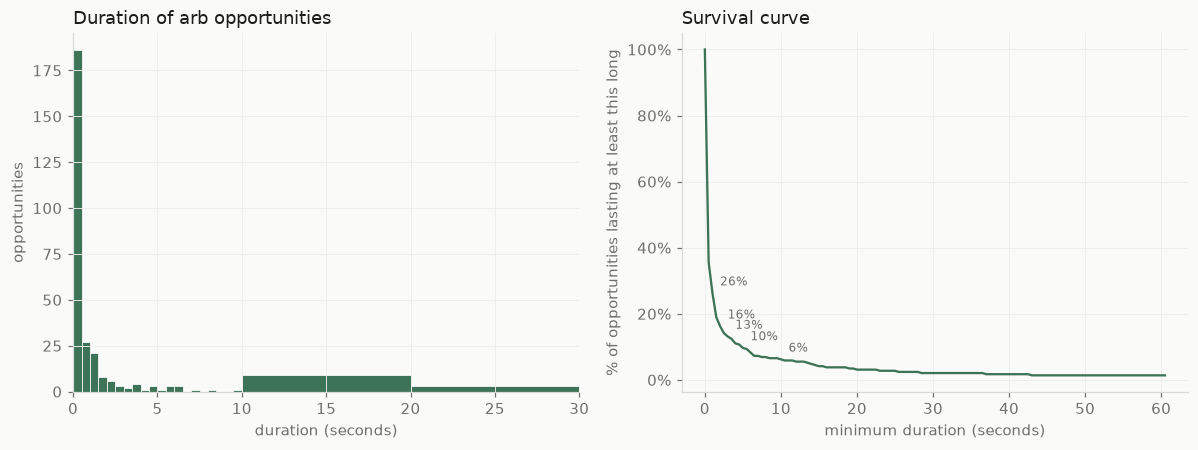

In [9]:
dur = episodes["duration_s"].to_numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Histogram
bins = np.concatenate([np.arange(0, 10, 0.5), [10, 20, 30, 60, 120, 300, 600]])
ax1.hist(dur, bins=bins, color=GREEN, edgecolor="white", linewidth=0.5)
ax1.set_xlabel("duration (seconds)")
ax1.set_ylabel("opportunities")
ax1.set_title("Duration of arb opportunities", color=INK)
ax1.set_xlim(0, 30)

# Survival curve
thresholds = np.arange(0, 61, 0.5)
survival = [np.mean(dur >= t) * 100 for t in thresholds]
ax2.plot(thresholds, survival, color=GREEN, lw=1.5)
ax2.set_xlabel("minimum duration (seconds)")
ax2.set_ylabel("% of opportunities lasting at least this long")
ax2.set_title("Survival curve", color=INK)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for t in [1, 2, 3, 5, 10]:
    pct = np.mean(dur >= t) * 100
    ax2.annotate(f"{pct:.0f}%", (t, pct), textcoords="offset points",
                 xytext=(5, 5), fontsize=8, color=MUTED)

fig.tight_layout()
plt.show()

In [10]:
duration_table = pl.DataFrame({
    "total": [len(dur)],
    "gte_1s": [int(np.sum(dur >= 1))],
    "gte_2s": [int(np.sum(dur >= 2))],
    "gte_3s": [int(np.sum(dur >= 3))],
    "gte_5s": [int(np.sum(dur >= 5))],
    "gte_10s": [int(np.sum(dur >= 10))],
    "gte_30s": [int(np.sum(dur >= 30))],
    "median_s": [float(np.median(dur))],
    "mean_s": [float(np.mean(dur))],
    "max_s": [float(np.max(dur))],
})

display(Markdown("**Duration counts**"))
duration_table.select(
    fmt_count("total").alias("total"),
    fmt_count("gte_1s").alias("≥1s"),
    fmt_count("gte_2s").alias("≥2s"),
    fmt_count("gte_3s").alias("≥3s"),
    fmt_count("gte_5s").alias("≥5s"),
    fmt_count("gte_10s").alias("≥10s"),
    fmt_count("gte_30s").alias("≥30s"),
)


**Duration counts**

total,≥1s,≥2s,≥3s,≥5s,≥10s,≥30s
"""289""","""76""","""47""","""38""","""28""","""18""","""6"""


In [11]:
display(Markdown("**Duration statistics**"))
duration_table.select(
    fmt_secs("median_s").alias("median"),
    fmt_secs("mean_s").alias("mean"),
    fmt_secs("max_s").alias("max"),
)

**Duration statistics**

median,mean,max
"""0.2s""","""4.9s""","""595.8s"""


### Executable?
Median duration is 0.2s — most opportunities close before an order could reach either exchange.\
76 of 289 (26%) last at least 1 second, 38 (13%) at least 3 seconds.\
Polymarket holds marketable sports orders for 1–3 seconds before matching,
so anything shorter than that window was likely never capturable.\
On the clock alone, that leaves at most 38–76 plausibly executable episodes over two days.

## How Big Are They?

Net arb per contract: the peak gross deviation during the episode minus both legs' taker fees.\
These are per-contract numbers — total profit also depends on the size available
at those prices (see Liquidity at the Touch).

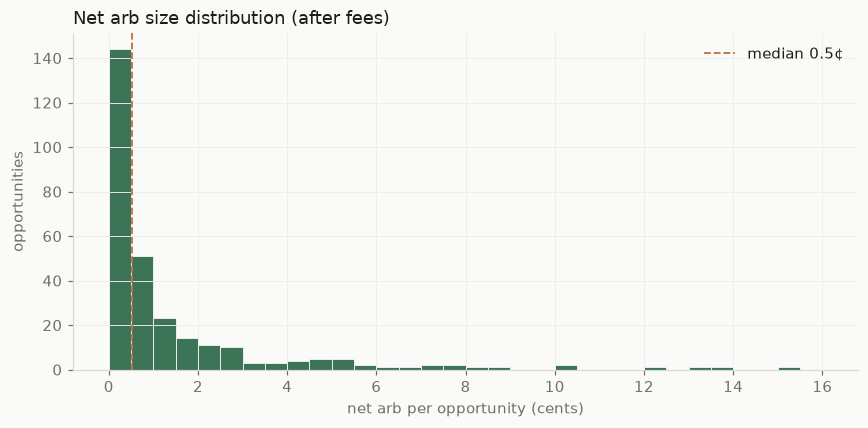

In [12]:
net = episodes["max_net_arb"].to_numpy() * 100  # cents

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, max(net) + 1, 0.5)
ax.hist(net, bins=bins, color=GREEN, edgecolor="white", linewidth=0.5)
ax.axvline(np.median(net), color=CLAY, ls="--", lw=1.2,
           label=f"median {np.median(net):.1f}¢")
ax.set_xlabel("net arb per opportunity (cents)")
ax.set_ylabel("opportunities")
ax.set_title("Net arb size distribution (after fees)", color=INK)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [13]:
size_stats = pl.DataFrame({
    "median_net": [float(np.median(net))],
    "mean_net": [float(np.mean(net))],
    "max_net": [float(np.max(net))],
    "gte_1c": [int(np.sum(net >= 1))],
    "gte_2c": [int(np.sum(net >= 2))],
    "gte_5c": [int(np.sum(net >= 5))],
    "gte_10c": [int(np.sum(net >= 10))],
})

# values already in cents, format directly
size_stats.select(
    pl.format("{}¢", pl.col("median_net").round(2)).alias("median"),
    pl.format("{}¢", pl.col("mean_net").round(2)).alias("mean"),
    pl.format("{}¢", pl.col("max_net").round(2)).alias("max"),
    fmt_count("gte_1c").alias("≥1¢"),
    fmt_count("gte_2c").alias("≥2¢"),
    fmt_count("gte_5c").alias("≥5¢"),
    fmt_count("gte_10c").alias("≥10¢"),
)

median,mean,max,≥1¢,≥2¢,≥5¢,≥10¢
"""0.51¢""","""1.44¢""","""15.38¢""","""94""","""57""","""21""","""6"""


Half the opportunities are worth less than 0.51¢ per contract.\
The distribution is heavily right-skewed: 6 episodes reach 10¢+,
and they pull the mean to nearly three times the median.

## Size vs Duration

Do the big opportunities last long enough to take?

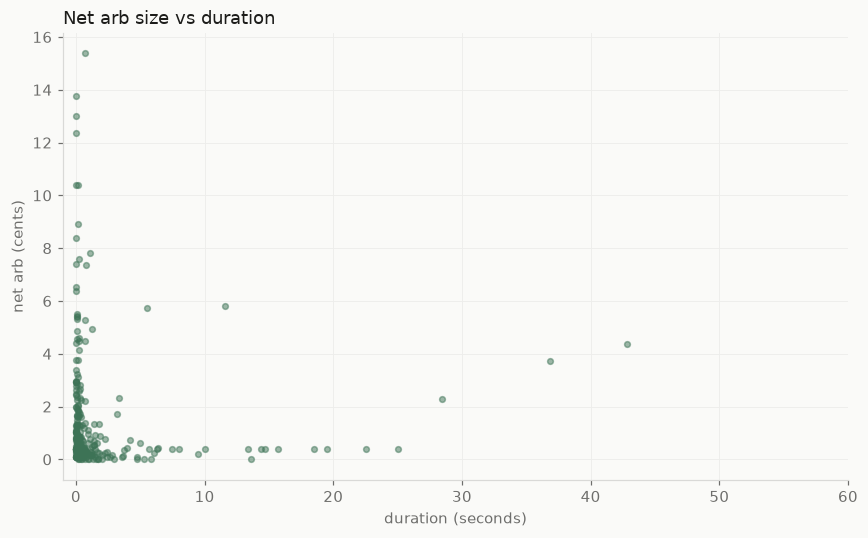

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(dur, net, s=14, alpha=0.5, color=GREEN, zorder=2)
ax.set_xlabel("duration (seconds)")
ax.set_ylabel("net arb (cents)")
ax.set_title("Net arb size vs duration", color=INK)
ax.set_xlim(-1, max(60, np.percentile(dur, 95) + 5))
fig.tight_layout()
plt.show()

Almost nothing is both big and durable.\
Of the 20 largest (Top Opportunities below), 17 close within a second,
and the three that persist past a second show at most 5 contracts at the touch.

## Liquidity at the Touch

A price is only takeable up to the size resting at it.\
Each episode's `min_size_at_touch` is the minimum contracts available across all four
book sides (Kalshi bid/ask, Polymarket bid/ask) while the episode was open —
the most that could have been arbed at the quoted prices.

In [15]:
min_size = episodes["min_size_at_touch"].to_numpy()

liq_table = pl.DataFrame({
    "total": [len(min_size)],
    "gte_1": [int(np.sum(min_size >= 1))],
    "gte_10": [int(np.sum(min_size >= 10))],
    "gte_50": [int(np.sum(min_size >= 50))],
    "gte_100": [int(np.sum(min_size >= 100))],
    "gte_500": [int(np.sum(min_size >= 500))],
})

liq_table.select(
    fmt_count("total").alias("total"),
    fmt_count("gte_1").alias("≥1"),
    fmt_count("gte_10").alias("≥10"),
    fmt_count("gte_50").alias("≥50"),
    fmt_count("gte_100").alias("≥100"),
    fmt_count("gte_500").alias("≥500"),
)

total,≥1,≥10,≥50,≥100,≥500
"""289""","""240""","""100""","""57""","""43""","""33"""


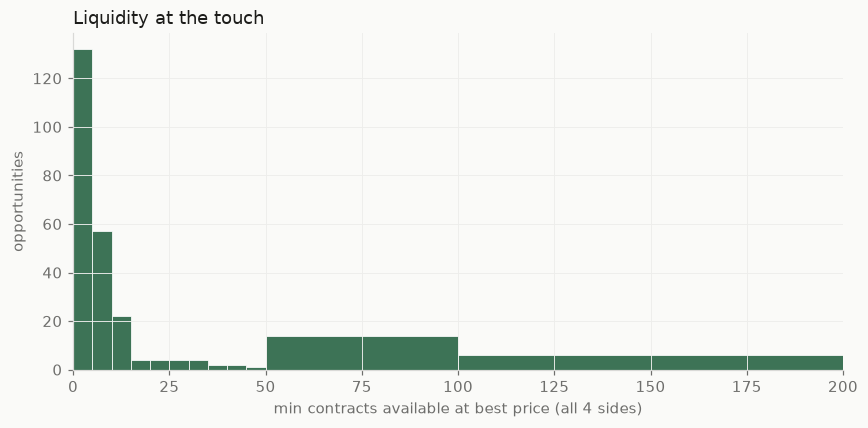

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.concatenate([np.arange(0, 50, 5), [50, 100, 250, 500, 1000, 2000]])
ax.hist(min_size, bins=bins, color=GREEN, edgecolor="white", linewidth=0.5)
ax.set_xlabel("min contracts available at best price (all 4 sides)")
ax.set_ylabel("opportunities")
ax.set_title("Liquidity at the touch", color=INK)
ax.set_xlim(0, 200)
fig.tight_layout()
plt.show()

### Executable?
240 of 289 have at least one contract at the touch, but only 100 have 10+ and 43 have 100+.\
Filling meaningful size would mean walking the book past the best price,
which eats directly into the arb.

## Top Opportunities

The 20 largest episodes by net arb.

In [17]:
episodes.sort("max_net_arb", descending=True).head(20).select(
    pl.col("game_key").str.replace(r"-\d{4}-\d{2}-\d{2}$", "").alias("game"),
    fmt_cents("max_gross_arb").alias("gross"),
    fmt_cents("avg_fee").alias("fee"),
    fmt_cents("max_net_arb").alias("net"),
    fmt_secs("duration_s").alias("duration"),
    pl.col("direction"),
    pl.col("min_size_at_touch").round(0).cast(pl.Int64).alias("min size"),
)

game,gross,fee,net,duration,direction,min size
"""KC@DET""","""18.5¢""","""3.2¢""","""15.38¢""","""0.7s""","""buy_poly""",1
"""KC@DET""","""16.0¢""","""2.25¢""","""13.75¢""","""0.0s""","""buy_kalshi""",10
"""ATL@BAL""","""15.5¢""","""2.22¢""","""13.01¢""","""0.0s""","""buy_kalshi""",10
"""NYY@PHI""","""15.5¢""","""3.11¢""","""12.38¢""","""0.0s""","""buy_kalshi""",0
"""TOR@BOS""","""12.5¢""","""1.83¢""","""10.41¢""","""0.1s""","""buy_kalshi""",4
"""NYY@PHI""","""13.5¢""","""3.12¢""","""10.38¢""","""0.0s""","""buy_kalshi""",0
"""KC@DET""","""12.0¢""","""3.13¢""","""8.91¢""","""0.2s""","""buy_kalshi""",5
"""NYY@PHI""","""11.5¢""","""3.12¢""","""8.38¢""","""0.0s""","""buy_kalshi""",3
"""NYY@PHI""","""11.0¢""","""3.24¢""","""7.82¢""","""1.1s""","""buy_poly""",5
"""AZ@WSH""","""8.5¢""","""0.97¢""","""7.57¢""","""0.3s""","""buy_poly""",10


The largest episode (KC@DET, 15.38¢ net) shows a single contract at the touch.\
Sub-second durations and single-digit sizes dominate the list.

## Platform Spread Comparison

How tight is each book?\
Measured across every recorded cross-platform state, not just arb episodes.

In [18]:
spread_stats = con.sql("""
    SELECT
        median(k_spread) AS kalshi_median,
        avg(k_spread) AS kalshi_mean,
        median(p_spread) AS poly_median,
        avg(p_spread) AS poly_mean
    FROM arb_states
""").pl()

spread_stats.select(
    fmt_cents("kalshi_median").alias("Kalshi median spread"),
    fmt_cents("kalshi_mean").alias("Kalshi mean spread"),
    fmt_cents("poly_median").alias("Poly median spread"),
    fmt_cents("poly_mean").alias("Poly mean spread"),
)

Kalshi median spread,Kalshi mean spread,Poly median spread,Poly mean spread
"""2.0¢""","""2.7¢""","""1.5¢""","""3.01¢"""


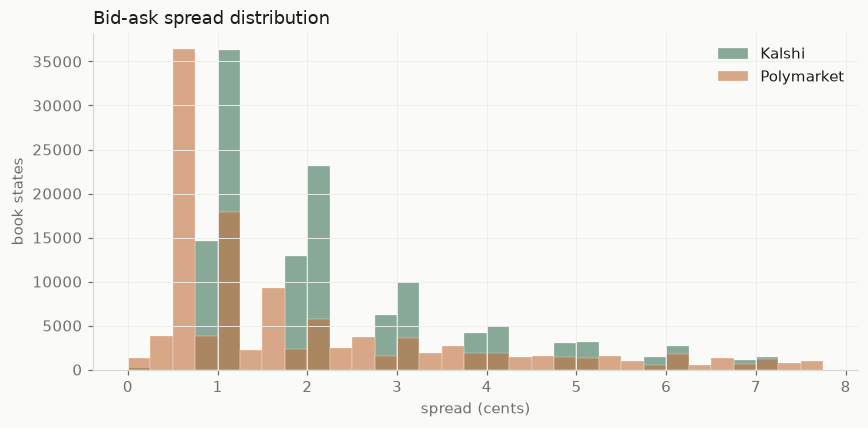

In [19]:
k_spreads = con.sql("SELECT k_spread FROM arb_states").pl()["k_spread"].to_numpy() * 100
p_spreads = con.sql("SELECT p_spread FROM arb_states").pl()["p_spread"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, 8, 0.25)
ax.hist(k_spreads, bins=bins, color=GREEN, alpha=0.6, label="Kalshi", edgecolor="white", linewidth=0.3)
ax.hist(p_spreads, bins=bins, color=CLAY, alpha=0.6, label="Polymarket", edgecolor="white", linewidth=0.3)
ax.set_xlabel("spread (cents)")
ax.set_ylabel("book states")
ax.set_title("Bid-ask spread distribution", color=INK)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Polymarket quotes tighter at the median (1.5¢ vs 2.0¢) but carries a fatter tail of
wide states, putting its mean (3.01¢) above Kalshi's (2.7¢).

## Findings

**289 arbitrage opportunities across 19 games in two days — about 15 per game.**\
The order books diverge 4,738 times, but 94% of those divergences
are smaller than the combined taker fees.

**Most are too fast to act on.**\
Median duration is 0.2 seconds. 26% last at least 1 second and 13% at least 3 seconds.
Given Polymarket's 1–3 second taker delay on sports markets, opportunities
shorter than that window are likely unexecutable — the book moves before the
matching engine processes the order.

**Most are thin.**\
Median net profit is 0.51¢ per contract. The fat ones (10¢+, 6 episodes)
close almost instantly: of the 20 largest, 17 last under one second.

**Liquidity is often inadequate.**\
Only 43 of 289 episodes have 100+ contracts at the best price on all four sides,
and just 100 have 10+. Executing meaningful volume would require walking the book,
eating into the margin.

**Polymarket sports fee caveat.**\
Third-party sources (unverified) report a sports-category theta of 0.03 vs the standard 0.06.
If true, the Polymarket leg fee halves, roughly doubling the number of opportunities.
This analysis uses the confirmed 0.06 theta.

**Two days is not enough to draw firm conclusions.**\
The patterns are suggestive but the sample is small.
More collection days would strengthen or weaken these findings.